# Experiment 2 — learning curves (LGD)

How R² scales with training-set size (no HPO; the four leading methods). Same structure as the PD notebook. Figures → `figures/experiment2/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, imbalance_curve, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2/lgd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2\lgd


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment2', task='lgd', aggregated=False)
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

4 methods, 4 datasets, 451 sweep points


## 1. R² vs training-set size — pooled over datasets

Four views of the same curve (one line per method, mean over datasets):
1. **raw points**, 2. **moving average** (trend), 3. **relative to each method's own best**, 4. the **moving average of that relative** curve.

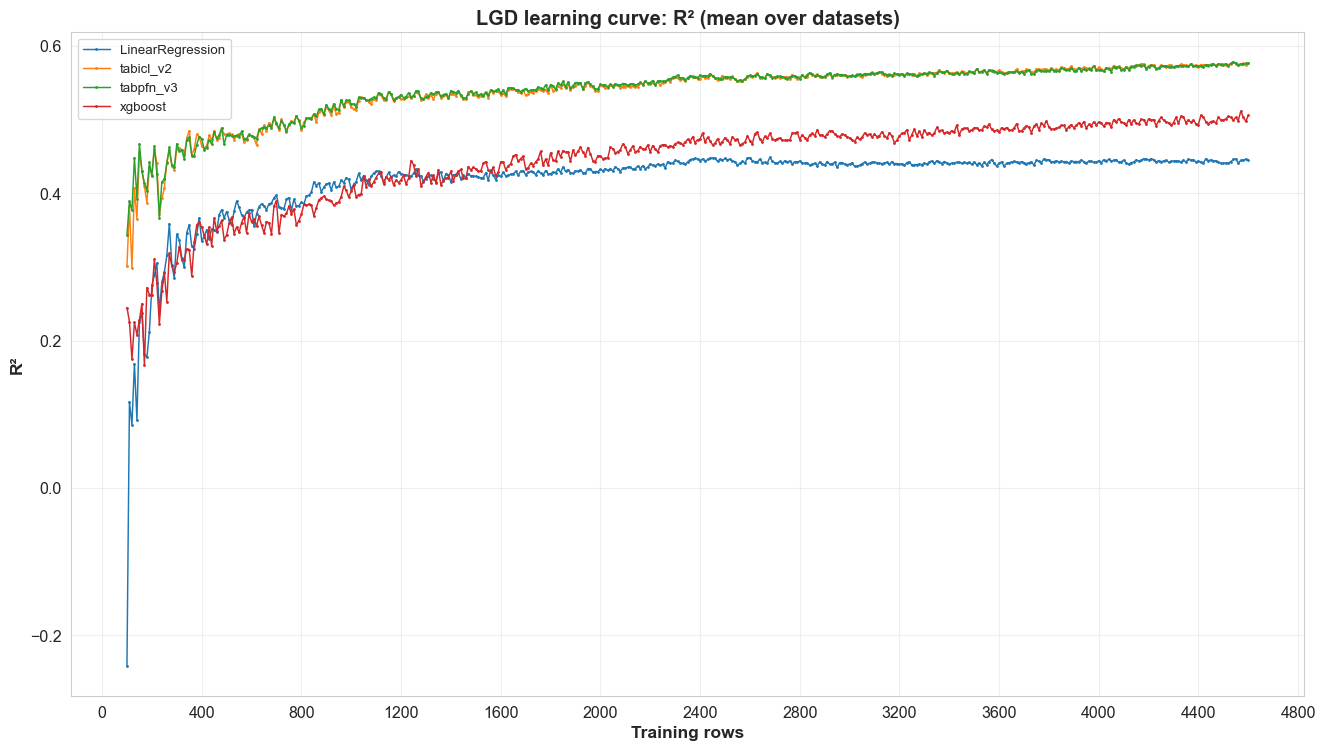

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2.pdf')

In [3]:
learning_curve(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

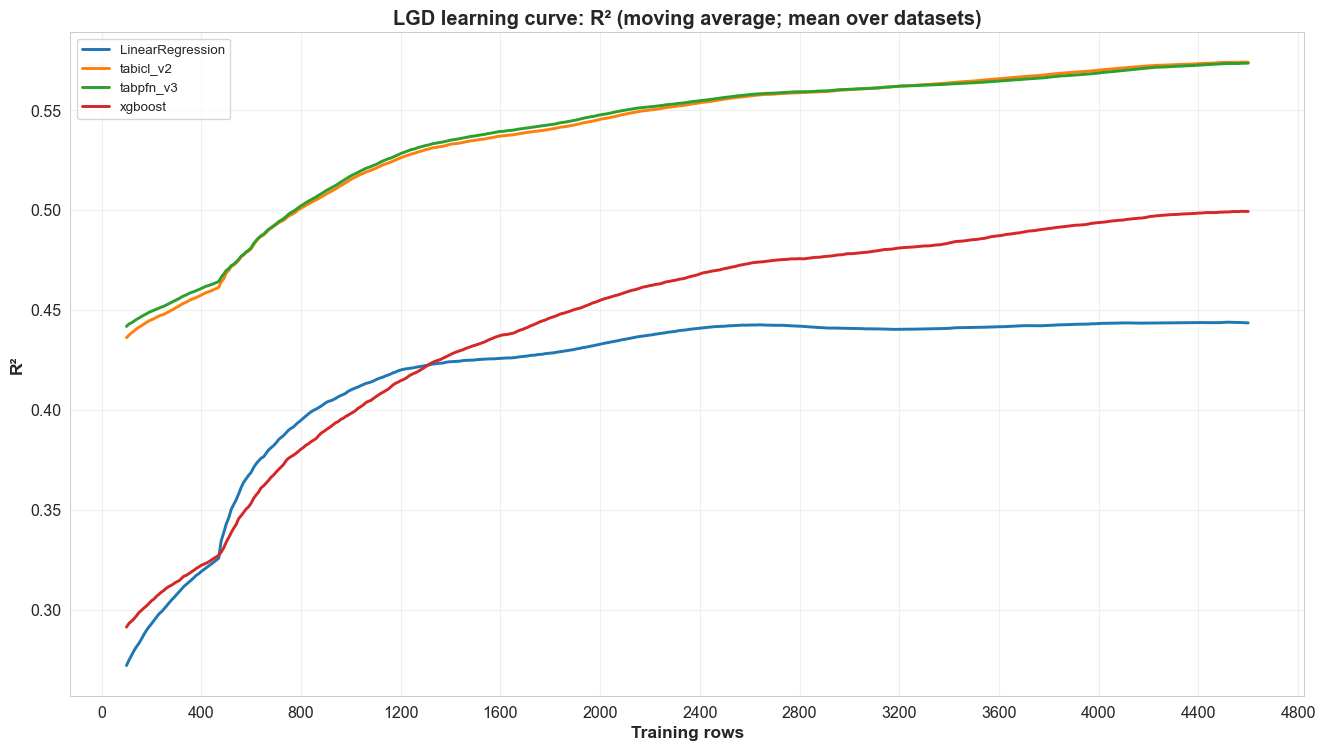

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_smooth.pdf')

In [4]:
learning_curve(df, 'R2', task_name='LGD', smooth=True, out_dir=FIGURES_DIR)

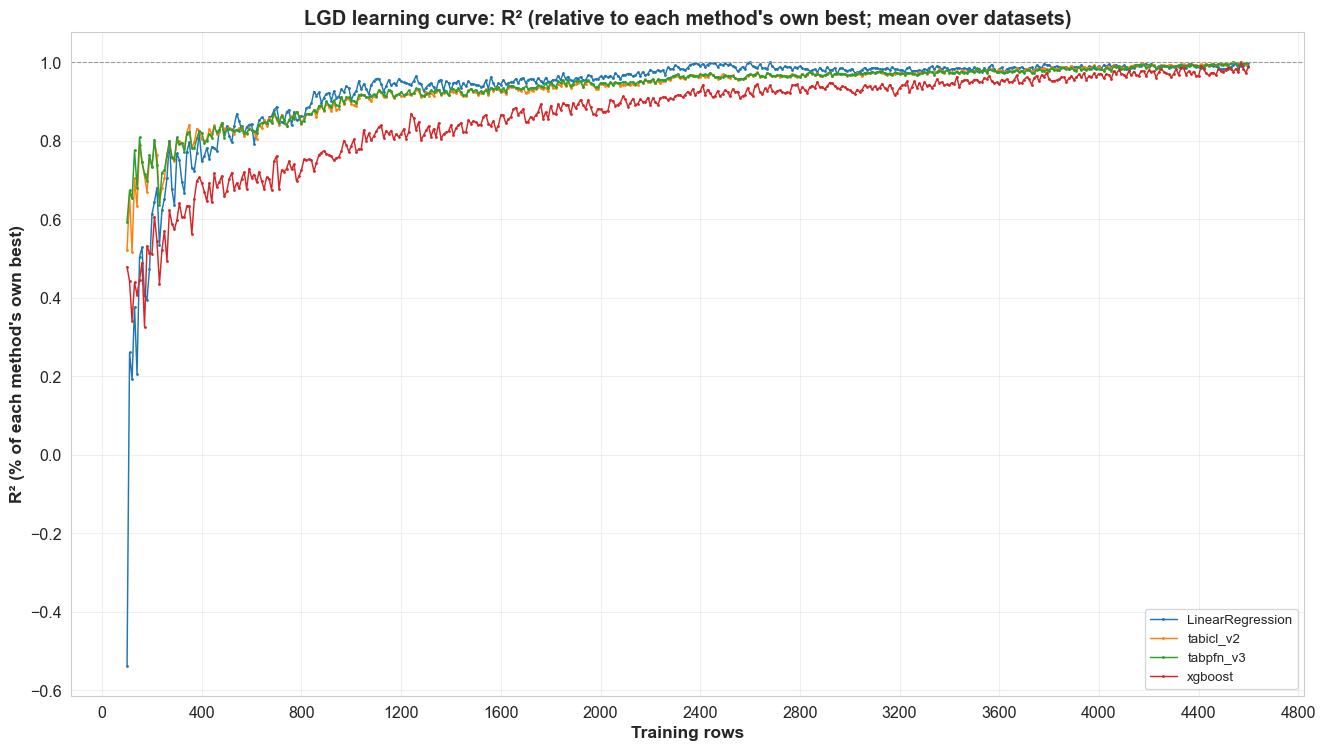

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_relative.pdf')

In [5]:
learning_curve(df, 'R2', task_name='LGD', relative=True, out_dir=FIGURES_DIR)

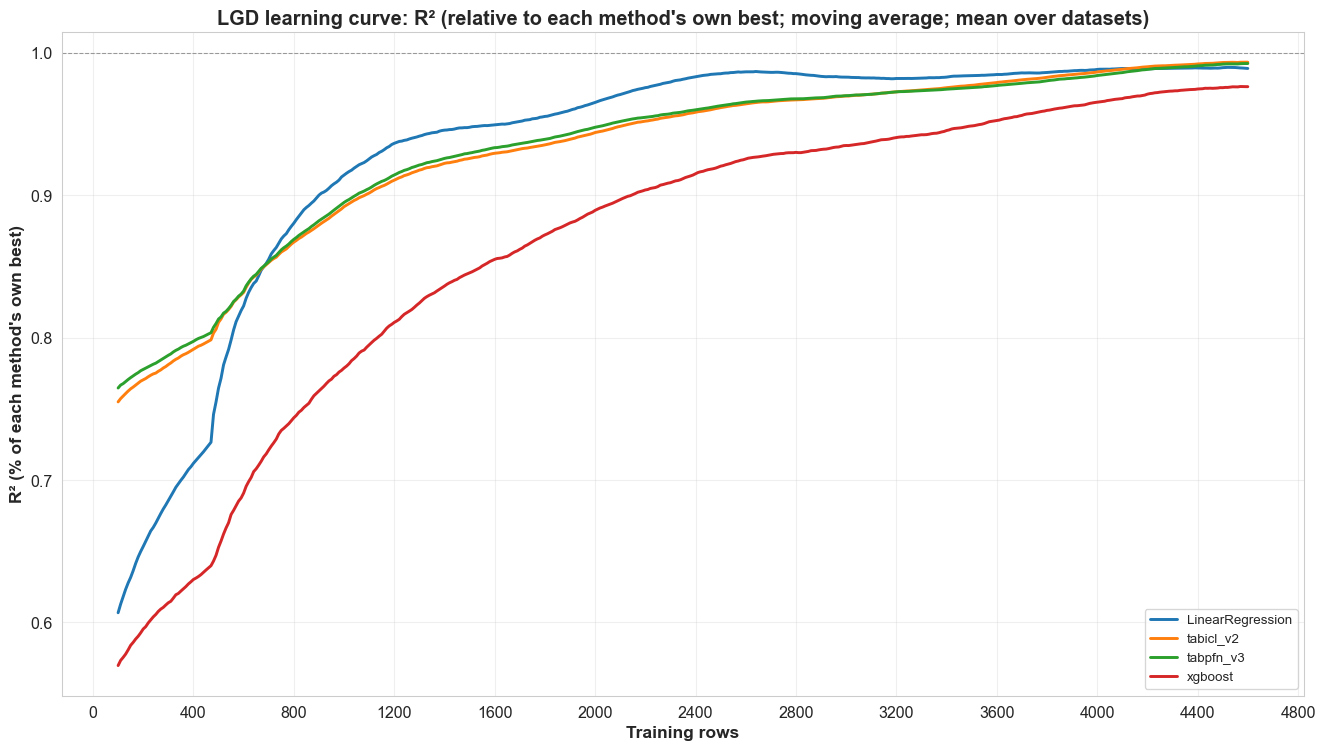

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_relative_smooth.pdf')

In [6]:
learning_curve(df, 'R2', task_name='LGD', relative=True, smooth=True, out_dir=FIGURES_DIR)

## 2. R² per dataset (raw points, all methods)

One plot per dataset so per-dataset behaviour is visible, not only the pooled mean.

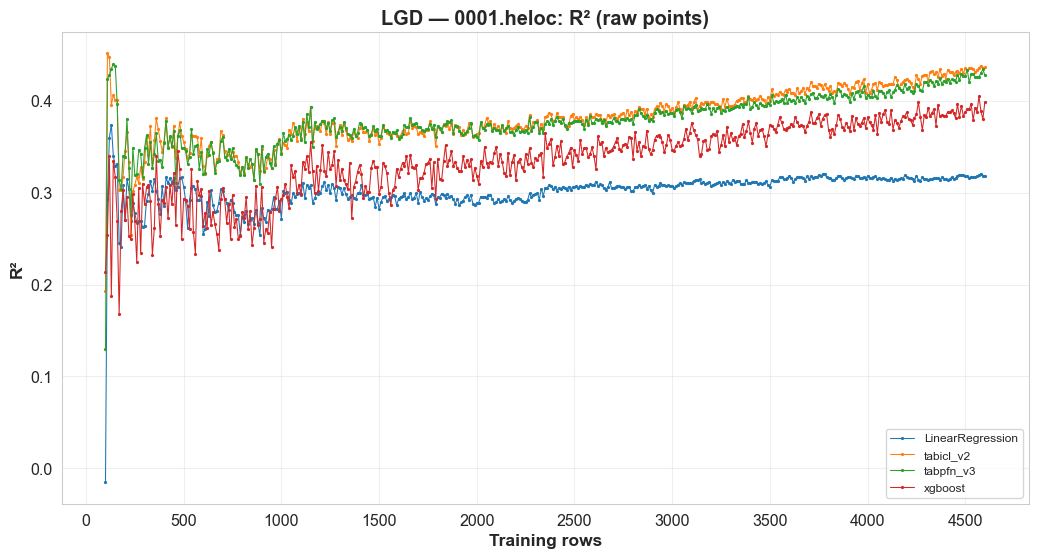

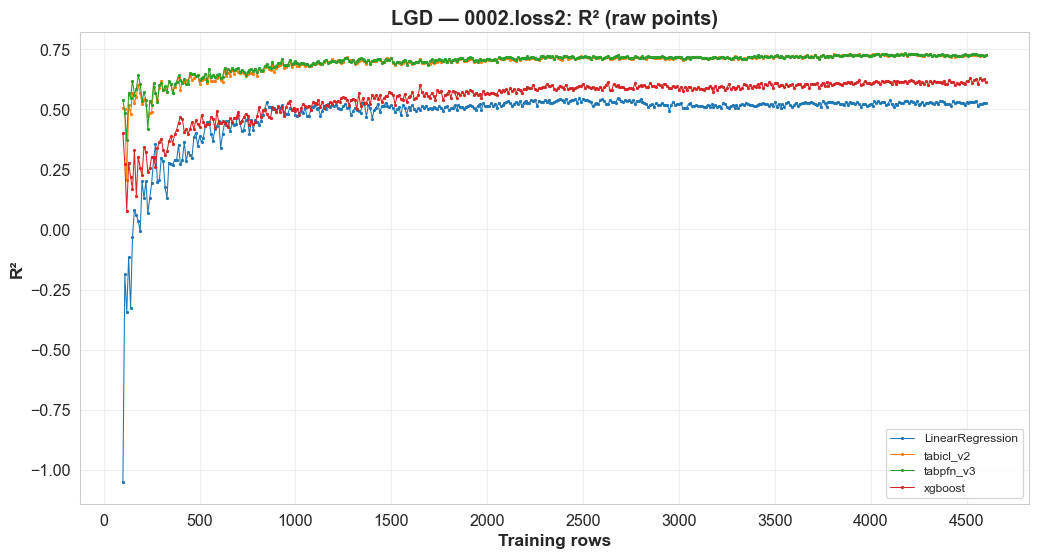

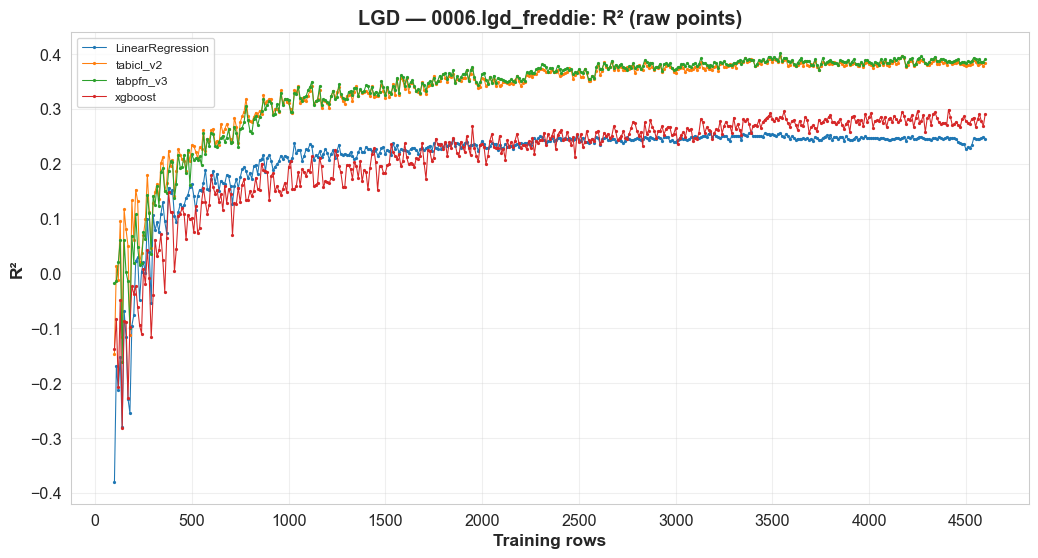

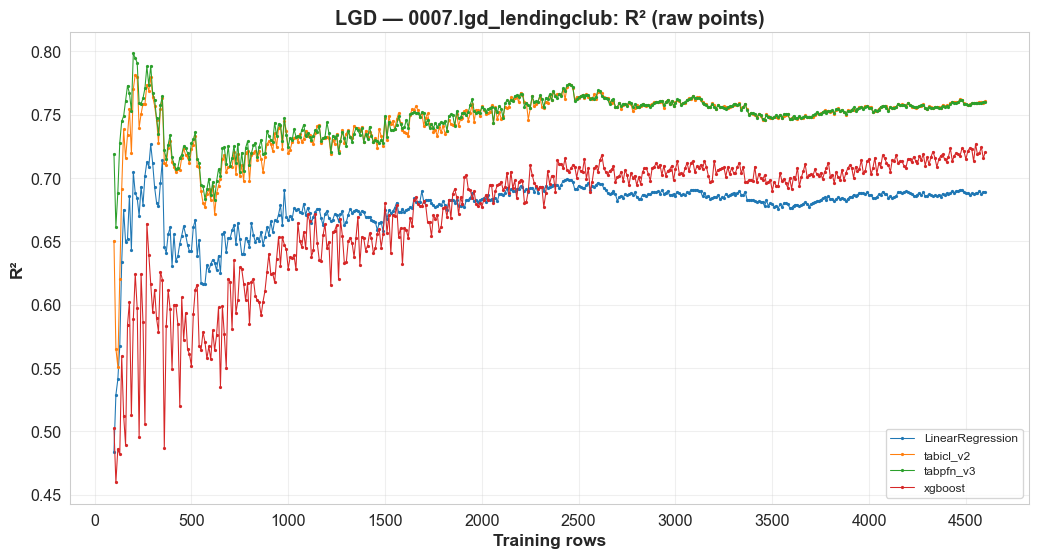

[WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0001_heloc_r2.pdf'),
 WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0002_loss2_r2.pdf'),
 WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0006_lgd_freddie_r2.pdf'),
 WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0007_lgd_lendingclub_r2.pdf')]

In [7]:
per_dataset_sweep_curves(df, 'R2', sweep_axis='row_limit', xlabel='Training rows', task_name='LGD', out_dir=FIGURES_DIR)

## 3. Data efficiency — training rows to reach 95% of each method's own plateau

In [8]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.R2'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.R2'].max() * 0.95
    hit = gg[gg['metric.R2'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
display(_pd.Series(rows, name='rows to reach 95% of own max R2').sort_values())

LinearRegression    1030
tabpfn_v3           1830
tabicl_v2           1920
xgboost             3230
Name: rows to reach 95% of own max R2, dtype: int64

## 4. Summary — R² evolution over training-set size

Mean R² per method across all datasets at a spread of training-set sizes.

In [9]:
sweep_evolution_summary(df, 'R2', sweep_axis='row_limit', task_name='Experiment 2 — LGD')

Experiment 2 — LGD — R² evolution over row_limit (mean across 4 datasets; 12 of 451 sweep points; best average first)
sweep_value         100     510     920     1330    1740    2150    2550    2960    3370    3780    4190    4600
method                                                                                                          
tabpfn_v3         0.3428  0.4786  0.5120  0.5339  0.5399  0.5481  0.5526  0.5607  0.5639  0.5653  0.5691  0.5761
tabicl_v2         0.3010  0.4815  0.5057  0.5281  0.5384  0.5443  0.5516  0.5610  0.5642  0.5685  0.5699  0.5765
xgboost           0.2447  0.3592  0.3888  0.4246  0.4422  0.4573  0.4731  0.4767  0.4852  0.4917  0.4934  0.5056
LinearRegression -0.2412  0.3641  0.4046  0.4196  0.4249  0.4367  0.4380  0.4412  0.4401  0.4468  0.4463  0.4446


'Experiment 2 — LGD — R² evolution over row_limit (mean across 4 datasets; 12 of 451 sweep points; best average first)\n=====================================================================================================================\nsweep_value         100     510     920     1330    1740    2150    2550    2960    3370    3780    4190    4600\nmethod                                                                                                          \ntabpfn_v3         0.3428  0.4786  0.5120  0.5339  0.5399  0.5481  0.5526  0.5607  0.5639  0.5653  0.5691  0.5761\ntabicl_v2         0.3010  0.4815  0.5057  0.5281  0.5384  0.5443  0.5516  0.5610  0.5642  0.5685  0.5699  0.5765\nxgboost           0.2447  0.3592  0.3888  0.4246  0.4422  0.4573  0.4731  0.4767  0.4852  0.4917  0.4934  0.5056\nLinearRegression -0.2412  0.3641  0.4046  0.4196  0.4249  0.4367  0.4380  0.4412  0.4401  0.4468  0.4463  0.4446'